# AdaptiveTokenizer — head-to-head comparison

**Goal**: benchmark the thesis adaptive-tokenization stack (A1, A2, A3 from
`docs/thesis_draft.md` §4.4) against the Assom 2025 baseline, using the
same segment embeddings, same evaluation protocol.

**Methods compared** (one row in the final table per method):

| # | Label | What |
|---|---|---|
| 1 | `assom` | Assom baseline — HDBSCAN + NCA on global UMAP (from reproduction) |
| 2 | `a1-only` | AcousticTokenizer: split / merge / add / prune on full-dim embeddings |
| 3 | `a1+bpe` | A1 followed by classical BPE bigram merging |
| 4 | `a1+pmi` | A1 followed by PMI-based merging (alternative) |
| 5 | `a1+bpe-iter` | Full iterative AdaptiveTokenizer (outer loop over A1 + BPE) |

**Metrics** (from `evaluation.full_evaluation`):

- `silhouette` — internal cluster quality on the chosen embedding
- `ari_proxy`, `nmi_proxy`, `types_per_emitter` — paper's qt_ward metric
- `ari_context`, `nmi_context` — diagnostic agreement with behavioural context
- `hp1_f1_original_{bos,inv}` / `hp1_f1_permuted_{bos,inv}` / `hp1_f1_delta_{bos,inv}`
  — associativity test with two feature bundles

**Setup**: embedding used for clustering is the **global UMAP 2-D space**
reused from the reproduction. For production you could re-run with the
192-D mel features directly, but UMAP is both cheaper and matches the
paper's design.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from src.adaptive_tokenizer import (
    AcousticTokenizer, AcousticTokenizerConfig,
    BPEMerger, PMIMerger, SequenceMergerConfig,
    AdaptiveTokenizer, AdaptiveTokenizerConfig,
    full_evaluation,
    default_acoustic_only, default_bpe, default_pmi,
    TokenizerState,
)

CHECKPOINT_DIR = Path('/Volumes/T7/cache/assom_paper_repro')
state_in = joblib.load(CHECKPOINT_DIR / 'ablation_state.joblib')

seg_df       = state_in['seg_df']
tf_specs     = state_in['tf_specs']             # (N, 6, 32) mel features
embedding    = state_in['embedding']            # (N, 2) global UMAP
hdb_labels   = state_in['hdbscan_labels']       # (N,)
hdbnca_lbl   = state_in['hdb_nca_labels']       # (N,)  after NCA noise reassign
SEQUENCES    = state_in['SEQUENCES']            # per-file sequence df (file_name index)
CONTEXT_DICT = state_in['CONTEXT_DICT']
RANDOM_STATE = state_in['RANDOM_STATE']

print(f'N segments: {len(seg_df)}')
print(f'Embedding: {embedding.shape}')
print(f'Global HDBSCAN clusters: {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}')
print(f'HP1 sequences: {len(SEQUENCES)}')


N segments: 53455
Embedding: (53455, 2)
Global HDBSCAN clusters: 6
HP1 sequences: 6545


## Build the inputs the tokenizer needs

- `X` — the embedding used for clustering (global UMAP)
- `sequences_per_file` — list of segment-index sequences grouped by file (original order preserved)
- `contexts_per_sequence` — majority context per file-sequence
- `emitters_per_segment`, `proxy_labels_per_segment` — needed for paper's ARI/NMI eval


In [2]:
# 1) per-file segment-index sequences in the original pos_segment order
sequences_per_file: list[list[int]] = []
context_per_sequence: list[int] = []
for fname, g in seg_df.sort_values('pos_segment').groupby('file_name', sort=False):
    seg_ids = g.index.to_list()
    if len(seg_ids) < 2:
        continue
    sequences_per_file.append(seg_ids)
    # majority context in this file
    ctx_vals = g['context'].to_numpy()
    context_per_sequence.append(int(np.bincount(ctx_vals).argmax()))

print(f'Built {len(sequences_per_file)} per-file sequences')
print(f'Length stats — median: {int(np.median([len(s) for s in sequences_per_file]))}, '
      f'max: {max(len(s) for s in sequences_per_file)}')

# 2) per-segment emitter + context
emitters_per_segment = seg_df['emitter'].to_numpy()
contexts_per_segment = seg_df['context'].to_numpy()

# 3) per-segment qt_ward proxy labels (filled during paper-repro run)
if 'proxy_label' in seg_df.columns:
    proxy_labels = seg_df['proxy_label'].to_numpy()
    print(f'proxy coverage: {(proxy_labels >= 0).mean():.1%}')
else:
    proxy_labels = None
    print('no proxy labels — qt_ward metrics will be skipped')


Built 6988 per-file sequences
Length stats — median: 5, max: 202
proxy coverage: 28.7%


## Baseline — Assom (reuse existing labels, wrap into a TokenizerState)

For a fair comparison we need the baseline in the same representation as the
adaptive results. `TokenizerState` accepts any pre-computed labels.


In [3]:
from src.adaptive_tokenizer.types import Token

def state_from_labels(labels: np.ndarray,
                     X: np.ndarray,
                     sequences_per_file: list[list[int]]) -> TokenizerState:
    tokens = {}
    for c in sorted(set(labels)):
        if c < 0:
            continue
        mids = np.where(labels == c)[0]
        tokens[int(c)] = Token(id=int(c),
                                 centroid=X[mids].mean(axis=0),
                                 member_ids=mids)
    sequences = []
    for seg_ids in sequences_per_file:
        tok_seq = [int(labels[i]) for i in seg_ids if labels[i] >= 0]
        if tok_seq:
            sequences.append(tok_seq)
    return TokenizerState(tokens=tokens, labels=np.asarray(labels, dtype=int), sequences=sequences)


baseline_state = state_from_labels(hdbnca_lbl, embedding, sequences_per_file)
print('Assom baseline as TokenizerState:', baseline_state.summary())


Assom baseline as TokenizerState: {'iteration': 0, 'vocab_size': 6, 'atomic': 6, 'composite': 0, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [20883, 11548, 9174, 6413, 3405], 'noise_fraction': 0.0, 'n_operations': 0}


## Run the 5 methods — one cell per method

If any method crashes, you only need to re-run that one cell (not all five).
The `results` dict persists in the kernel across cells.


In [4]:
# Shared init — run this once before the per-method cells below
import time, copy
results: dict[str, 'TokenizerState'] = {}

_shared_ac_cfg = dict(
    seed_min_cluster_frac=0.01,
    seed_min_samples=20,
    seed_epsilon=0.1,
    seed_method='leaf',
    split_silhouette_threshold=0.40,
    add_outlier_quantile=0.95,
    add_min_size=50,
    prune_min_size=50,
    random_state=RANDOM_STATE,
)
_shared_seq_cfg = dict(
    max_merges=30,
    min_bigram_count=30,
    min_sequences_containing=10,
)
print(f'results dict ready: {len(results)} methods so far')


results dict ready: 0 methods so far


### Method 1 — Assom baseline (instant, no fit)


In [5]:
results['assom'] = baseline_state
print(f'[1/5] assom baseline: {baseline_state.summary()}')


[1/5] assom baseline: {'iteration': 0, 'vocab_size': 6, 'atomic': 6, 'composite': 0, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [20883, 11548, 9174, 6413, 3405], 'noise_fraction': 0.0, 'n_operations': 0}


### Method 2 — A1 only (AcousticTokenizer with split/merge/add/prune)


In [6]:
t0 = time.time()
tok_a1 = default_acoustic_only(AcousticTokenizerConfig(max_iterations=3, **_shared_ac_cfg))
state_a1 = tok_a1.acoustic.fit(embedding, seed_labels=hdbnca_lbl,
                                 sequences_per_file=sequences_per_file)
results['a1-only'] = state_a1
print(f'[2/5] a1-only took {time.time()-t0:.1f}s')
print(f'     summary: {state_a1.summary()}')


A1 acoustic iter:   0%|          | 0/3 [00:00<?, ?it/s]

A1 iter 1 split:   0%|          | 0/1 [00:00<?, ?it/s]

A1 iter 1 merge: 0it [00:00, ?it/s]

A1 iter 2 split:   0%|          | 0/1 [00:00<?, ?it/s]

A1 iter 2 merge: 0it [00:00, ?it/s]

A1 iter 3 split:   0%|          | 0/3 [00:00<?, ?it/s]

A1 iter 3 merge: 0it [00:00, ?it/s]

[2/5] a1-only took 16.0s
     summary: {'iteration': 3, 'vocab_size': 10, 'atomic': 10, 'composite': 0, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [14717, 13767, 11650, 9174, 6413], 'noise_fraction': 0.0, 'n_operations': 10}


### Method 3 — A1 + BPE (single pass)

Reuses `state_a1` — fast.


In [7]:
t0 = time.time()
state_a1_bpe = copy.deepcopy(state_a1)
bpe = BPEMerger(SequenceMergerConfig(**_shared_seq_cfg))
bpe.fit(state_a1_bpe)
results['a1+bpe'] = state_a1_bpe
print(f'[3/5] a1+bpe took {time.time()-t0:.1f}s')
print(f'     summary: {state_a1_bpe.summary()}')


bpe merge:   0%|          | 0/30 [00:00<?, ?it/s]

[3/5] a1+bpe took 0.2s
     summary: {'iteration': 3, 'vocab_size': 40, 'atomic': 10, 'composite': 30, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [186400, 116500, 93200, 81550, 69900], 'noise_fraction': 0.0, 'n_operations': 40}


### Method 4 — A1 + PMI (single pass)

Alternative merger — PMI instead of raw frequency.


In [8]:
t0 = time.time()
state_a1_pmi = copy.deepcopy(state_a1)
pmi = PMIMerger(SequenceMergerConfig(pmi_threshold=0.3, **_shared_seq_cfg))
pmi.fit(state_a1_pmi)
results['a1+pmi'] = state_a1_pmi
print(f'[4/5] a1+pmi took {time.time()-t0:.1f}s')
print(f'     summary: {state_a1_pmi.summary()}')


pmi merge:   0%|          | 0/30 [00:00<?, ?it/s]

[4/5] a1+pmi took 0.4s
     summary: {'iteration': 3, 'vocab_size': 40, 'atomic': 10, 'composite': 30, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [73392, 52283, 51304, 49522, 47652], 'noise_fraction': 0.0, 'n_operations': 40}


### Method 5 — A1 + BPE with outer iterative loop (full AdaptiveTokenizer)

Heaviest — full iterative refinement. Atomic tokens that are children of
composites are "locked" and protected from acoustic ops (regression fix).


In [9]:
t0 = time.time()
tok_iter = AdaptiveTokenizer(AdaptiveTokenizerConfig(
    acoustic=AcousticTokenizerConfig(max_iterations=2, **_shared_ac_cfg),
    sequence=SequenceMergerConfig(**_shared_seq_cfg),
    sequence_kind='bpe',
    max_outer_iters=3,
    verbose=True,
))
state_iter = tok_iter.fit(embedding, seed_labels=hdbnca_lbl,
                            sequences_per_file=sequences_per_file)
results['a1+bpe-iter'] = state_iter
print(f'[5/5] a1+bpe-iter took {time.time()-t0:.1f}s')
print(f'     summary: {state_iter.summary()}')


A1 acoustic iter:   0%|          | 0/2 [00:00<?, ?it/s]

A1 iter 1 split:   0%|          | 0/1 [00:00<?, ?it/s]

A1 iter 1 merge: 0it [00:00, ?it/s]

A1 iter 2 split:   0%|          | 0/1 [00:00<?, ?it/s]

A1 iter 2 merge: 0it [00:00, ?it/s]

...

[outer 2] acoustic pass: vocab=55, any_op=True


bpe merge:   0%|          | 0/30 [00:00<?, ?it/s]

[outer 3] sequence pass: vocab 55 -> 55


A1 iter 3 merge: 0it [00:00, ?it/s]

[outer 3] acoustic pass: vocab=54, any_op=True
[5/5] a1+bpe-iter took 19.6s
     summary: {'iteration': 3, 'vocab_size': 54, 'atomic': 7, 'composite': 47, 'n_segments': 53455, 'n_sequences': 6988, 'top5_token_sizes': [186400, 139800, 128150, 116500, 104850], 'noise_fraction': 0.0, 'n_operations': 63}


### Checkpoint: save all fitted states to disk

This way a later failure in evaluation doesn't discard the 30+ minutes
of fitting work. Re-runs of the evaluation cell just reload from here.


In [10]:
_STATES_CKPT = CHECKPOINT_DIR / 'adaptive_tokenizer_states.joblib'
joblib.dump({
    'results':              results,
    'context_per_sequence': context_per_sequence,
    'sequences_per_file':   sequences_per_file,
}, _STATES_CKPT, compress=3)
print(f'Saved fitted states to {_STATES_CKPT}  '
      f'({_STATES_CKPT.stat().st_size // (1024*1024)} MB)')


Saved fitted states to /Volumes/T7/cache/assom_paper_repro/adaptive_tokenizer_states.joblib  (7 MB)


## Evaluate all five methods with the unified eval function

This cell is safe to re-run alone: if `results` is not defined in the
kernel it loads from the checkpoint saved in the cell above.


In [11]:
from tqdm.auto import tqdm

# Allow re-running evaluation without re-fitting
if 'results' not in globals() or not results:
    _state = joblib.load(CHECKPOINT_DIR / 'adaptive_tokenizer_states.joblib')
    results = _state['results']
    context_per_sequence = _state['context_per_sequence']
    sequences_per_file = _state['sequences_per_file']
    print(f'Loaded {len(results)} methods from checkpoint')

rows = []
method_bar = tqdm(results.items(), desc='Evaluating methods', total=len(results))
for name, st in method_bar:
    method_bar.set_postfix_str(name)
    res = full_evaluation(
        st,
        embedding=embedding,
        contexts_per_segment=contexts_per_segment,
        contexts_per_sequence=context_per_sequence,
        proxy_labels=proxy_labels,
        emitters=emitters_per_segment,
        run_hp1=True,
        hp1_feature_bundles=('bos', 'inv'),
        random_state=RANDOM_STATE,
        method_label=name,
    )
    row = {'method': name}
    row.update(res.vocab_breakdown)
    row.update(res.metrics)
    rows.append(row)
method_bar.close()

results_df = pd.DataFrame(rows)
# keep only interesting columns in a compact view
display_cols = [
    'method', 'vocab_size', 'atomic_vocab_size', 'composite_vocab_size',
    'silhouette', 'noise_fraction',
    'types_per_emitter', 'ari_proxy', 'nmi_proxy',
    'ari_context', 'nmi_context',
    'hp1_f1_original_bos', 'hp1_f1_permuted_bos', 'hp1_f1_delta_bos',
    'hp1_f1_original_inv', 'hp1_f1_permuted_inv', 'hp1_f1_delta_inv',
]
display_cols = [c for c in display_cols if c in results_df.columns]
print('\n=== Head-to-head table ===')
print(results_df[display_cols].to_string(index=False))


Evaluating methods:   0%|          | 0/5 [00:00<?, ?it/s]

eval[assom]:   0%|          | 0/5 [00:00<?, ?it/s]

per-emitter ARI/NMI:   0%|          | 0/41 [00:00<?, ?it/s]

eval[a1-only]:   0%|          | 0/5 [00:00<?, ?it/s]

per-emitter ARI/NMI:   0%|          | 0/41 [00:00<?, ?it/s]

...

eval[a1+pmi]:   0%|          | 0/5 [00:00<?, ?it/s]

per-emitter ARI/NMI:   0%|          | 0/41 [00:00<?, ?it/s]

eval[a1+bpe-iter]:   0%|          | 0/5 [00:00<?, ?it/s]

per-emitter ARI/NMI:   0%|          | 0/41 [00:00<?, ?it/s]


=== Head-to-head table ===
     method  vocab_size  atomic_vocab_size  composite_vocab_size  silhouette  noise_fraction  types_per_emitter  ari_proxy  nmi_proxy  ari_context  nmi_context  hp1_f1_original_bos  hp1_f1_permuted_bos  hp1_f1_delta_bos  hp1_f1_original_inv  hp1_f1_permuted_inv  hp1_f1_delta_inv
      assom           6                  6                     0    0.426204             0.0               22.7   0.117112   0.407600     0.231032     0.265634             0.468583             0.468583               0.0             0.772529             0.772529               0.0
    a1-only          10                 10                     0    0.322646             0.0               22.7   0.122125   0.407365     0.219842     0.233514             0.547680             0.547680               0.0             0.921896             0.921896               0.0
     a1+bpe          40                 10                    30    0.322646             0.0               22.7   0.122125   0.40736

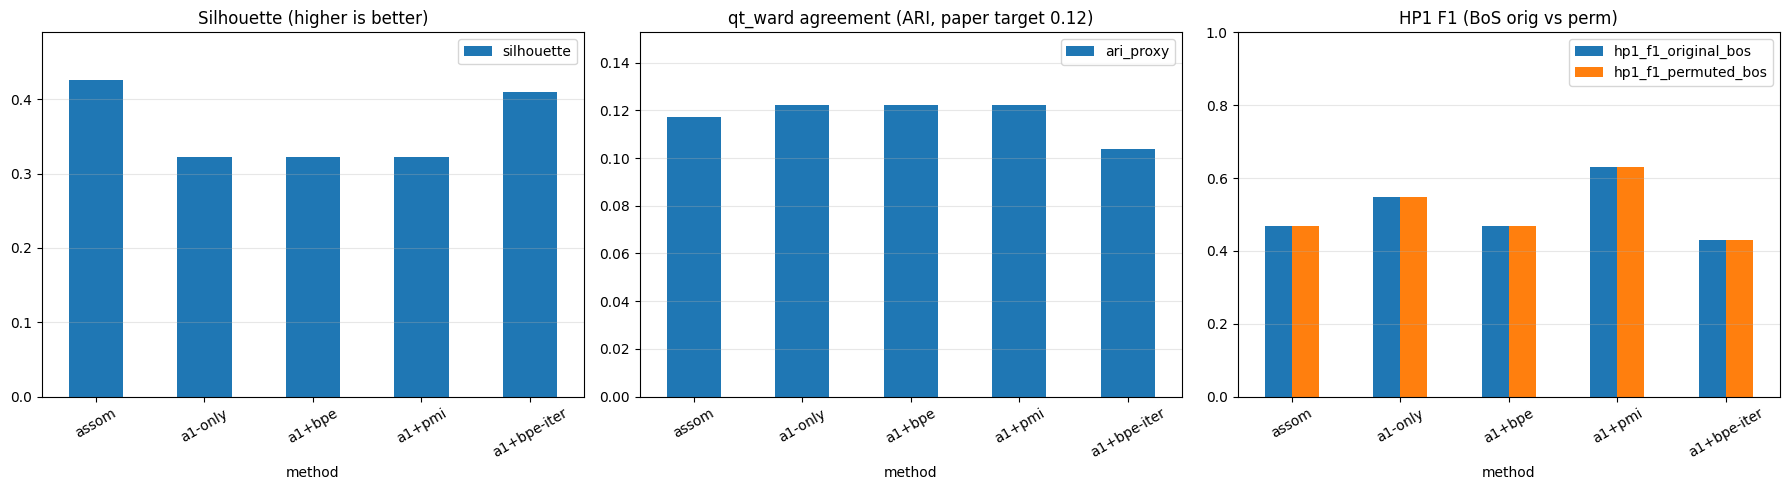

In [12]:
# Visualise as a grouped bar chart for the key metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, cols, ylim) in zip(axes, [
    ('Silhouette (higher is better)',
     ['silhouette'], (0, max(0.01, results_df['silhouette'].max() * 1.15))),
    ('qt_ward agreement (ARI, paper target 0.12)',
     ['ari_proxy'], (0, max(0.01, (results_df.get('ari_proxy', pd.Series([0])).max() or 0) * 1.25))),
    ('HP1 F1 (BoS orig vs perm)',
     ['hp1_f1_original_bos', 'hp1_f1_permuted_bos'], (0, 1)),
]):
    if not any(c in results_df.columns for c in cols):
        ax.set_visible(False); continue
    sub = results_df[['method'] + [c for c in cols if c in results_df.columns]]
    sub.set_index('method').plot.bar(ax=ax, rot=30)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Interpretation checklist

After running the cells above, read the table with the following questions:

1. **Does A1-only improve silhouette over Assom baseline?**
   If yes, split/merge/add/prune found finer-grained structure that
   fixed-HDBSCAN missed. If no, our parameters are off.

2. **Does A1+BPE keep the HP1 Δ close to zero while raising `ari_proxy`?**
   This is the sweet spot: we got a richer vocabulary without introducing
   spurious order-dependence.

3. **Does PMI merge a different set of bigrams than BPE?**
   Compare `composite_vocab_size` and inspect `state.history`:
   PMI should favour pairs with high log p(a,b)/p(a)p(b), BPE will follow
   raw frequency. Expected: PMI creates fewer composites, but more
   linguistically meaningful ones.

4. **Does the outer iterative loop (`a1+bpe-iter`) add beyond single-pass BPE?**
   If yes — it's worth paying the compute. If the metrics are
   indistinguishable, keep the cheaper single-pass variant.

5. **types_per_emitter vs paper's 27 ± 2**:
   Baseline was 22.7 ± 3.6. Does adaptive push closer to 27? If so, adaptive
   splitting actually recovered the missing ~5 types.

6. **HP1 Δ (original − permuted)**:
   For the associativity claim to hold under adaptive tokenization, Δ should
   stay near 0. If it becomes positive for the richer-vocabulary methods,
   it means: with a finer vocabulary, order actually starts to carry
   information. That's a legitimately interesting finding — a bigger
   vocabulary gives order-sensitive tests more statistical power.


In [13]:
# Save all states + results table to disk for later analysis (e.g. thesis figures)
OUT = CHECKPOINT_DIR / 'adaptive_tokenizer_results.joblib'
joblib.dump({
    'states': results,
    'results_df': results_df,
    'config_info': {
        'embedding': 'global UMAP 2D',
        'seed_labels': 'hdb_nca_labels from paper reproduction',
        'random_state': RANDOM_STATE,
    },
}, OUT, compress=3)
print(f'Saved {OUT}  ({OUT.stat().st_size // (1024*1024)} MB)')


Saved /Volumes/T7/cache/assom_paper_repro/adaptive_tokenizer_results.joblib  (7 MB)
